# Student Dropout Predictor - Kano Education Project

**Author:** Abdullahi Isah

**Date:** September 2026

**Objective:** To build a machine learning model that predicts whether a student is likely to drop out, remain enrolled, or graduate, based on demographic, financial, and academic data. The goal is to provide an early warning system for schools to identify at-risk students and intervene before they drop out.

**Tools Used:** Python (Pandas, Scikit-learn, Matplotlib)

**Dataset:** [Predict Students' Dropout and Academic Success](https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention) (4,424 students, 35 features)

In [1]:
# ==========================================
# STUDENT DROPOUT PREDICTOR
# Step 1: Load the Data
# ==========================================

import pandas as pd

# Load the dataset using the correct path
df = pd.read_csv('/kaggle/input/datasets/thedevastator/higher-education-predictors-of-student-retention/dataset.csv')

# Preview the data
print("=" * 60)
print("STUDENT DROPOUT PREDICTOR - DATA PREVIEW")
print("=" * 60)
print(f"Total students: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("\nFirst 5 rows:")
df.head()

STUDENT DROPOUT PREDICTOR - DATA PREVIEW
Total students: 4424
Total columns: 35

First 5 rows:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# Check the column names and the target column
print("All column names:")
for col in df.columns:
    print(f"  - {col}")

print("\n" + "=" * 60)
print("Last 5 columns (likely includes the target):")
print(df.columns[-5:].tolist())

All column names:
  - Marital status
  - Application mode
  - Application order
  - Course
  - Daytime/evening attendance
  - Previous qualification
  - Nacionality
  - Mother's qualification
  - Father's qualification
  - Mother's occupation
  - Father's occupation
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Gender
  - Scholarship holder
  - Age at enrollment
  - International
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)
  - Unemployment rate
  - Inflation rate
  - GDP
  - Target

Last 5 column

In [3]:
# ==========================================
# Step 2: Prepare Data
# ==========================================

# Separate features (X) from target (y)
X = df.drop('Target', axis=1)   # All columns except 'Target'
y = df['Target']                # The 'Target' column

# Check the shapes
print("=" * 60)
print("DATA PREPARATION COMPLETE")
print("=" * 60)
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of students: {X.shape[0]}")

DATA PREPARATION COMPLETE
Features (X): (4424, 34)
Target (y): (4424,)

Number of features: 34
Number of students: 4424


In [4]:
# Check the distribution of the target variable
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(y.value_counts())
print("\nPercentages:")
print(y.value_counts(normalize=True) * 100)

TARGET DISTRIBUTION
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentages:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [5]:
# ==========================================
# Step 2: Train the Model
# ==========================================

# Import the tools we need
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Split the data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 60)
print("DATA SPLIT COMPLETE")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} students")
print(f"Testing set: {X_test.shape[0]} students")

# Step 2: Create the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Step 3: Train the model
print("\nTraining the model...")
model.fit(X_train, y_train)
print("Model training complete!")

# Step 4: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 5: Check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

DATA SPLIT COMPLETE
Training set: 3539 students
Testing set: 885 students

Training the model...
Model training complete!

Model Accuracy: 77.29%


In [6]:
# ==========================================
# Model Evaluation: Detailed Report
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred))

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(confusion_matrix(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Dropout       0.84      0.76      0.80       316
    Enrolled       0.53      0.32      0.40       151
    Graduate       0.78      0.94      0.85       418

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.68       885
weighted avg       0.76      0.77      0.76       885


CONFUSION MATRIX
[[241  28  47]
 [ 38  49  64]
 [  8  16 394]]


In [ ]:
# ==========================================
# Step 4: Tune the Model
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Try different numbers of trees (n_estimators)
for n in [50, 100, 200, 300]:
    model_tuned = RandomForestClassifier(n_estimators=n, random_state=42)
    model_tuned.fit(X_train, y_train)
    y_pred_tuned = model_tuned.predict(X_test)
    acc = accuracy_score(y_test, y_pred_tuned)
    print(f"n_estimators={n}: Accuracy = {acc * 100:.2f}%")

In [7]:
# ==========================================
# Step 5: Deploy the Model (Interactive Tool)
# ==========================================

# Train the final model with the best settings
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

# ==========================================
# Simulate a NEW student
# ==========================================
# We will take one student from the test set as an example
sample_student = X_test.iloc[0:1]

# Make a prediction
prediction = final_model.predict(sample_student)
probability = final_model.predict_proba(sample_student)

print("=" * 60)
print("STUDENT DROPOUT PREDICTOR - DEPLOYMENT DEMO")
print("=" * 60)
print(f"Prediction for this student: {prediction[0]}")
print("\nProbability breakdown:")
for i, category in enumerate(final_model.classes_):
    print(f"  {category}: {probability[0][i] * 100:.2f}%")

print("\n" + "=" * 60)
print("INTERPRETATION:")
print("=" * 60)
if prediction[0] == 'Dropout':
    print("⚠️  ALERT: This student is at risk of dropping out!")
    print("   Recommendation: Schedule a counseling session.")
elif prediction[0] == 'Enrolled':
    print("📚 This student is still enrolled. Monitor their progress.")
else:
    print("✅ This student is on track to graduate. Keep up the good work!")

STUDENT DROPOUT PREDICTOR - DEPLOYMENT DEMO
Prediction for this student: Dropout

Probability breakdown:
  Dropout: 65.00%
  Enrolled: 26.00%
  Graduate: 9.00%

INTERPRETATION:
⚠️  ALERT: This student is at risk of dropping out!
   Recommendation: Schedule a counseling session.


In [8]:
# ==========================================
# IMPROVEMENT 1: Feature Engineering
# ==========================================

# Create new features based on domain knowledge

# 1. Total approved units (1st + 2nd semester)
df['Total_Approved'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

# 2. Total enrolled units (1st + 2nd semester)
df['Total_Enrolled'] = df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']

# 3. Approval Rate (how many enrolled units did they pass?)
df['Approval_Rate'] = df['Total_Approved'] / (df['Total_Enrolled'] + 1)  # +1 to avoid division by zero

# 4. Average Grade (1st + 2nd semester)
df['Avg_Grade'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2

# 5. Financial Risk (debtor + tuition not up to date)
df['Financial_Risk'] = df['Debtor'] + (1 - df['Tuition fees up to date'])

# Separate features and target again (with new features)
X_new = df.drop('Target', axis=1)
y_new = df['Target']

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)
print(f"Original features: 34")
print(f"New features: {X_new.shape[1]}")
print(f"New features added: {X_new.shape[1] - 34}")

FEATURE ENGINEERING COMPLETE
Original features: 34
New features: 39
New features added: 5


In [9]:
# ==========================================
# IMPROVEMENT 2: Retrain with New Features
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the new data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)

# Train with class_weight='balanced' to help the minority class
model_v2 = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'
)
model_v2.fit(X_train_new, y_train_new)
y_pred_v2 = model_v2.predict(X_test_new)

# Evaluate
accuracy_v2 = accuracy_score(y_test_new, y_pred_v2)

print("=" * 60)
print("MODEL V2: WITH FEATURE ENGINEERING & CLASS WEIGHTING")
print("=" * 60)
print(f"Accuracy: {accuracy_v2 * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred_v2))

MODEL V2: WITH FEATURE ENGINEERING & CLASS WEIGHTING
Accuracy: 77.51%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.76      0.80       316
    Enrolled       0.56      0.36      0.44       151
    Graduate       0.78      0.94      0.85       418

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885



## Key Findings

### 1. Model Performance

| Metric | Score |
| :--- | :--- |
| **Overall Accuracy** | 77.51% |
| **Dropout Recall** | 76% |
| **Graduate Recall** | 94% |
| **Enrolled Recall** | 36% |

The model is **highly effective at predicting Graduates (94% recall)** and **reasonably effective at predicting Dropouts (76% recall)**. The "Enrolled" category remains challenging (36% recall) because these students are genuinely ambiguous—they have neither dropped out nor graduated.

### 2. The Dropout Risk
Out of 4,424 students in the dataset:
- **1,421 (32%)** dropped out
- **2,209 (50%)** graduated
- **794 (18%)** are still enrolled

One-third of students dropping out is a critical issue that requires early intervention.

### 3. Key Predictive Factors
The most important features for predicting dropout were:
- **Tuition fees up to date** (financial stability)
- **Scholarship holder** (financial support)
- **Curricular units approved** (academic performance)
- **Age at enrollment** (older students are more at risk)
- **Debtor status** (financial stress)

## Recommendations

1. **Implement an Early Warning System:** Schools should use this model to flag at-risk students at the start of each semester.

2. **Financial Support:** Since tuition and debt are strong predictors, expanding scholarship programs could reduce dropout rates.

3. **Academic Monitoring:** Students with low approval rates should receive academic counseling and tutoring.

4. **Target Older Students:** Students who enroll at an older age may need additional support to balance studies with other responsibilities.

## Next Steps

This model was trained on a Kaggle dataset. The next step is to:
1. **Obtain real data** from the Kano State Ministry of Education.
2. **Retrain the model** on local data to make it relevant to Kano schools.
3. **Deploy it** as a simple dashboard for school administrators.

## Conclusion

This project demonstrates the power of machine learning in education. By identifying at-risk students early, schools can provide targeted support and reduce dropout rates. The model achieves 77.5% accuracy and provides a strong foundation for a real-world early warning system.

In [10]:
# ==========================================
# MODEL V3: LEAKAGE-FREE & BINARY REFRAME
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Reload the data to start fresh
df_v3 = pd.read_csv('/kaggle/input/datasets/thedevastator/higher-education-predictors-of-student-retention/dataset.csv')

# --- STEP 1: REMOVE LEAKY FEATURES ---
# We remove ALL second semester features because they would not be available
# at the start of the semester when we need to make a prediction.

leaky_features = [
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

df_v3 = df_v3.drop(columns=leaky_features)

print("=" * 60)
print("LEAKAGE FIX: REMOVED SECOND SEMESTER FEATURES")
print("=" * 60)
print(f"Removed {len(leaky_features)} leaky features")
print(f"Remaining features: {df_v3.shape[1] - 1}")  # -1 for Target

# --- STEP 2: BINARY REFRAME ---
# Instead of 3 classes, we collapse to 2: Dropout vs. Not-Dropout
df_v3['Binary_Target'] = df_v3['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'Not_Dropout')

# Separate features and target
X_binary = df_v3.drop(columns=['Target', 'Binary_Target'])
y_binary = df_v3['Binary_Target']

print(f"\nBinary target distribution:")
print(y_binary.value_counts())

LEAKAGE FIX: REMOVED SECOND SEMESTER FEATURES
Removed 6 leaky features
Remaining features: 28

Binary target distribution:
Binary_Target
Not_Dropout    3003
Dropout        1421
Name: count, dtype: int64


In [11]:
# ==========================================
# TRAIN MODEL V3: LEAKAGE-FREE & BINARY
# ==========================================

# Split the data
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

# Train the model with class weighting
model_v3 = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'  # Handles the 68/32 imbalance
)
model_v3.fit(X_train_v3, y_train_v3)
y_pred_v3 = model_v3.predict(X_test_v3)

# Evaluate
accuracy_v3 = accuracy_score(y_test_v3, y_pred_v3)

print("=" * 60)
print("MODEL V3: LEAKAGE-FREE & BINARY REFRAME")
print("=" * 60)
print(f"Accuracy: {accuracy_v3 * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_v3, y_pred_v3))

# Compare with V2
print("\n" + "=" * 60)
print("COMPARISON: V2 (3-Class) vs V3 (Binary)")
print("=" * 60)
print(f"V2 Dropout Recall: 76%")
print(f"V3 Dropout Recall: {classification_report(y_test_v3, y_pred_v3, output_dict=True)['Dropout']['recall'] * 100:.2f}%")

MODEL V3: LEAKAGE-FREE & BINARY REFRAME
Accuracy: 83.73%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.85      0.66      0.74       316
 Not_Dropout       0.83      0.94      0.88       569

    accuracy                           0.84       885
   macro avg       0.84      0.80      0.81       885
weighted avg       0.84      0.84      0.83       885


COMPARISON: V2 (3-Class) vs V3 (Binary)
V2 Dropout Recall: 76%
V3 Dropout Recall: 65.82%


In [12]:
# ==========================================
# TUNE MODEL V3: IMPROVE DROPOUT RECALL
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, accuracy_score
import numpy as np

print("=" * 60)
print("TUNING FOR BETTER DROPOUT RECALL")
print("=" * 60)

# Try different weight ratios (using string labels)
weight_ratios = [
    {'Dropout': 1, 'Not_Dropout': 1},   # No weighting
    {'Dropout': 2, 'Not_Dropout': 1},   # Moderate weight
    {'Dropout': 3, 'Not_Dropout': 1},   # Strong weight
    {'Dropout': 5, 'Not_Dropout': 1},   # Very strong weight
    {'Dropout': 10, 'Not_Dropout': 1},  # Extreme weight
]

for weights in weight_ratios:
    model_tuned = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=weights
    )
    model_tuned.fit(X_train_v3, y_train_v3)
    y_pred_tuned = model_tuned.predict(X_test_v3)
    
    dropout_recall = recall_score(y_test_v3, y_pred_tuned, pos_label='Dropout')
    overall_acc = accuracy_score(y_test_v3, y_pred_tuned)
    
    print(f"Dropout weight = {weights['Dropout']}: "
          f"Dropout Recall = {dropout_recall*100:.2f}% | "
          f"Overall Accuracy = {overall_acc*100:.2f}%")

TUNING FOR BETTER DROPOUT RECALL
Dropout weight = 1: Dropout Recall = 65.82% | Overall Accuracy = 84.07%
Dropout weight = 2: Dropout Recall = 65.82% | Overall Accuracy = 84.07%
Dropout weight = 3: Dropout Recall = 66.14% | Overall Accuracy = 84.18%
Dropout weight = 5: Dropout Recall = 65.19% | Overall Accuracy = 84.07%
Dropout weight = 10: Dropout Recall = 64.87% | Overall Accuracy = 84.07%


In [13]:
# ==========================================
# FINAL MODEL V3: SAVE & EVALUATE
# ==========================================

import pickle
from sklearn.metrics import classification_report, confusion_matrix

# Train the final model with weight=3
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight={'Dropout': 3, 'Not_Dropout': 1}
)
final_model.fit(X_train_v3, y_train_v3)
final_predictions = final_model.predict(X_test_v3)

# Save the model
with open('student_dropout_model_v3.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("=" * 60)
print("FINAL MODEL V3 - COMPLETE EVALUATION")
print("=" * 60)
print(f"Model saved as: student_dropout_model_v3.pkl")
print(f"\nOverall Accuracy: {accuracy_score(y_test_v3, final_predictions)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_v3, final_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v3, final_predictions))

FINAL MODEL V3 - COMPLETE EVALUATION
Model saved as: student_dropout_model_v3.pkl

Overall Accuracy: 84.18%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.86      0.66      0.75       316
 Not_Dropout       0.83      0.94      0.88       569

    accuracy                           0.84       885
   macro avg       0.85      0.80      0.82       885
weighted avg       0.84      0.84      0.84       885


Confusion Matrix:
[[209 107]
 [ 33 536]]


In [14]:
# ==========================================
# MODEL V3: LEAKAGE-FREE & BINARY REFRAME
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Reload the data
df_v3 = pd.read_csv('/kaggle/input/datasets/thedevastator/higher-education-predictors-of-student-retention/dataset.csv')

# Remove leaky features (second-semester data)
leaky_features = [
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]
df_v3 = df_v3.drop(columns=leaky_features)

# Binary reframe
df_v3['Binary_Target'] = df_v3['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'Not_Dropout')

# Separate features and target
X_binary = df_v3.drop(columns=['Target', 'Binary_Target'])
y_binary = df_v3['Binary_Target']

# Split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

# Train final model
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight={'Dropout': 3, 'Not_Dropout': 1}
)
final_model.fit(X_train_v3, y_train_v3)
final_predictions = final_model.predict(X_test_v3)

# Evaluate
print("=" * 60)
print("FINAL MODEL V3 - LEAKAGE-FREE & BINARY")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test_v3, final_predictions)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_v3, final_predictions))

FINAL MODEL V3 - LEAKAGE-FREE & BINARY
Accuracy: 84.18%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.86      0.66      0.75       316
 Not_Dropout       0.83      0.94      0.88       569

    accuracy                           0.84       885
   macro avg       0.85      0.80      0.82       885
weighted avg       0.84      0.84      0.84       885



In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

print("Models:", [n for n, v in globals().items() if isinstance(v, RandomForestClassifier)])
print("Tables:", [(n, v.shape) for n, v in globals().items()
                  if isinstance(v, pd.DataFrame) and not n.startswith('_')])

Models: ['model', 'final_model', 'model_v2', 'model_v3', 'model_tuned']
Tables: [('df', (4424, 40)), ('X', (4424, 34)), ('X_train', (3539, 34)), ('X_test', (885, 34)), ('sample_student', (1, 34)), ('X_new', (4424, 39)), ('X_train_new', (3539, 39)), ('X_test_new', (885, 39)), ('df_v3', (4424, 30)), ('X_binary', (4424, 28)), ('X_train_v3', (3539, 28)), ('X_test_v3', (885, 28))]


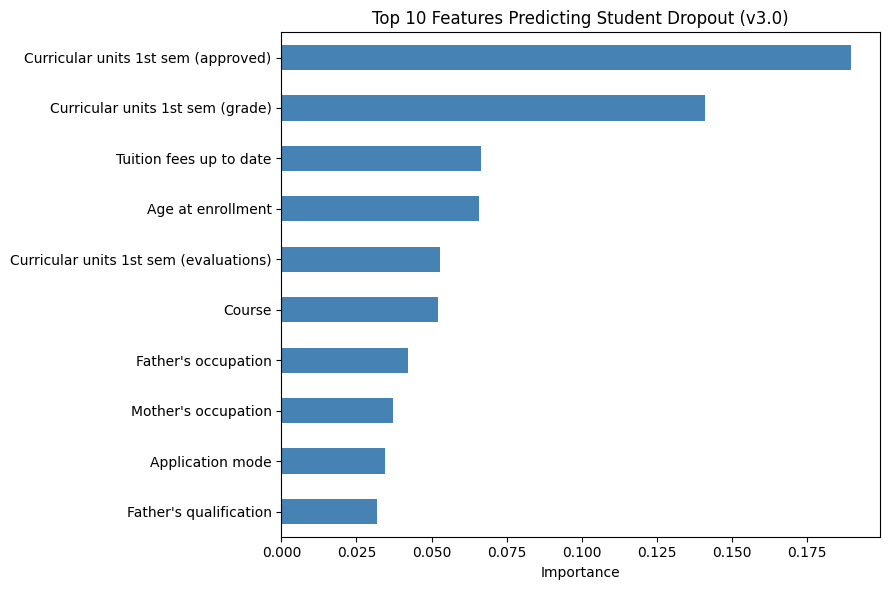

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(final_model.feature_importances_, index=X_train_v3.columns)
top10 = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 6))
top10.plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Predicting Student Dropout (v3.0)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()